# Phase 5 — Advanced Experiments

**SupportAI · Notebook 06** — run on **Google Colab (T4 GPU)**.

Phases 0–4 built the core: classification is solved (LogReg 0.995 / DistilBERT 0.999) and a QLoRA-fine-tuned Mistral-7B drafts on-brand replies (ROUGE-L 0.358). Phase 5 explores four advanced directions that make the system *smarter and cheaper to operate*:

| # | Experiment | Question it answers |
|---|-----------|---------------------|
| **A** | **RAG over historical responses** | Does grounding generation in similar past tickets beat fine-tuning alone? |
| **B** | **Active learning** | How few labels do we actually need to hit production F1? |
| **C** | **Prompt engineering (CoT)** | Can better prompting close the LLM's classification gap on *hard* tickets? |
| **D** | **Multi-task learning** | Can one shared encoder predict `category` **and** `intent` as well as two separate models? |

### Notes
- **Reuses the Phase 4 Mistral adapter** (`mistral_qlora_gen`) for RAG generation — make sure it's on Drive (see the data cell). Falls back to base Mistral with a warning if missing.
- **Multi-task scope**: a shared *encoder* can't emit free-text generation (that needs a decoder), so "multi-task" here = shared DistilBERT encoder with **two classification heads** (`category` 11-way + `intent` 27-way, both already in the dataset). True joint classification+generation would need an encoder-decoder — noted as future work.
- Outputs: `experiments/phase5_results.csv` + a learning-curve plot. Findings in `06_Advanced_Experiments_FINDINGS.md`.

## 1. Setup

Install the stack (LLM + sentence-transformers + FAISS), check the GPU, and set constants. Same bitsandbytes-unpinned trick as Phase 4 (the new Colab triton breaks bnb 0.43.x).

In [1]:
# =============================================================
# 1a. Install the stack (Colab)
# =============================================================
# bitsandbytes UNPINNED (latest) for the new Colab triton — see Phase 4.
# Adds sentence-transformers + faiss-cpu (RAG) on top of the LLM stack.
%pip install -q -U bitsandbytes
%pip install -q \
    "transformers==4.44.2" \
    "peft==0.13.2" \
    "accelerate==0.34.2" \
    "datasets==2.21.0" \
    "evaluate==0.4.3" \
    "rouge_score==0.1.2" \
    "sentence-transformers" \
    "faiss-cpu" \
    "matplotlib"

print("✅ Install complete. If imports fail, Runtime > Restart session, then run from the top.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 138.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 104.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [2]:
# =============================================================
# 1b. Imports, GPU check, constants
# =============================================================
import torch, random, numpy as np

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MISTRAL_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"     # reuses the Phase-4 adapter
EMBED_MODEL   = "sentence-transformers/all-MiniLM-L6-v2" # RAG retriever
RAG_K         = 3                                        # neighbors per query
GEN_INPUT_MAX = 1024                                     # RAG prompts are long
MODELS_DIR, EXPERIMENTS_DIR = "models", "experiments"

assert torch.cuda.is_available(), (
    "No CUDA GPU. Colab: Runtime > Change runtime type > GPU (T4). "
    "Experiments A/C/D need the GPU; B is CPU-only.")
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name} | {gpu.total_memory/1e9:.1f} GB | torch {torch.__version__}")

GPU: Tesla T4 | 15.6 GB | torch 2.11.0+cu128


## 2. Data, Phase-1/4 artifacts & shared helpers

Mount Drive and load the dataset, the **Phase-1 TF-IDF + LogReg** (reused for active learning and to pick the hard CoT subset), and locate the **Phase-4 Mistral adapter** for RAG generation. Same 70/15/15 split as every prior notebook.

> **Put these in your Drive folder** (`DRIVE_DIR`): `customer_support_clean.csv`, `label_encoder.pkl`, `tfidf_vectorizer.pkl`, `lr_tfidf.pkl` (all small, committed in the repo), and the `mistral_qlora_gen/` adapter folder from Phase 4 (optional — RAG falls back to base Mistral if absent).

In [4]:
# =============================================================
# 2a. Mount Drive, load data + Phase-1 artifacts, locate adapter
# =============================================================
# Needs in your Drive folder (DRIVE_DIR):
#   customer_support_clean.csv, label_encoder.pkl   (data)
#   tfidf_vectorizer.pkl, lr_tfidf.pkl              (Phase-1 model, for AL + CoT hard-set)
#   mistral_qlora_gen/                              (Phase-4 adapter, for RAG gen) — optional
import os, pandas as pd, joblib
from sklearn.model_selection import train_test_split

DRIVE_DIR = "/content/drive/MyDrive/Colab_Notebooks/ML"
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    DRIVE_DIR = "."

def _find(*candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    raise FileNotFoundError("None of these exist:\n  " + "\n  ".join(map(str, candidates)))

DATA_CSV  = _find(os.path.join(DRIVE_DIR, "customer_support_clean.csv"), "customer_support_clean.csv", "../data/customer_support_clean.csv")
LE_PATH   = _find(os.path.join(DRIVE_DIR, "label_encoder.pkl"), "label_encoder.pkl", "../models/label_encoder.pkl")
TFIDF_PATH= _find(os.path.join(DRIVE_DIR, "tfidf_vectorizer.pkl"), "tfidf_vectorizer.pkl", "../models/tfidf_vectorizer.pkl")
LR_PATH   = _find(os.path.join(DRIVE_DIR, "lr_tfidf.pkl"), "lr_tfidf.pkl", "../models/lr_tfidf.pkl")

df = pd.read_csv(DATA_CSV)
label_encoder = joblib.load(LE_PATH)
tfidf = joblib.load(TFIDF_PATH)
lr_model = joblib.load(LR_PATH)
CATEGORIES = list(label_encoder.classes_)
df["label"] = label_encoder.transform(df["category"])

# Same 70/15/15 stratified split as every prior notebook (seed 42)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

# Locate the Phase-4 Mistral adapter (Drive first; None -> RAG falls back to base)
ADAPTER_DIR = None
for cand in [os.path.join(DRIVE_DIR, "mistral_qlora_gen"),
             os.path.join(DRIVE_DIR, "models", "mistral_qlora_gen"),
             "models/mistral_qlora_gen"]:
    if os.path.isdir(cand):
        ADAPTER_DIR = cand
        break

print(f"Rows: {len(df)} | categories: {len(CATEGORIES)} | intents: {df['intent'].nunique()}")
print(f"Split: train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")
print(f"Phase-1 LogReg + TF-IDF loaded. Mistral adapter: {ADAPTER_DIR or 'NOT FOUND (will use base)'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 26872 | categories: 11 | intents: 27
Split: train=18810  val=4031  test=4031
Phase-1 LogReg + TF-IDF loaded. Mistral adapter: /content/drive/MyDrive/Colab_Notebooks/ML/mistral_qlora_gen


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or

In [5]:
# =============================================================
# 2b. Shared LLM helpers (used by RAG generation + CoT)
# =============================================================
import os, torch
import evaluate as hf_evaluate
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, PeftModel

_rouge = hf_evaluate.load("rouge")
TOKENIZER_CACHE = {}

GEN_INSTRUCTION = ("You are a helpful customer-support agent. Write a concise, polite "
                   "reply to the following customer message.\n\nCustomer: {query}")

def build_text(tokenizer, user_content, assistant_content=None):
    """Chat template when available (Mistral), else a plain instruct fallback."""
    if getattr(tokenizer, "chat_template", None):
        msgs = [{"role": "user", "content": user_content}]
        if assistant_content is None:
            return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        msgs.append({"role": "assistant", "content": assistant_content})
        return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    return f"Instruct: {user_content}\nOutput:" if assistant_content is None \
        else f"Instruct: {user_content}\nOutput: {assistant_content}{tokenizer.eos_token}"

def load_causal_lm(name, quantized=True):
    tok = TOKENIZER_CACHE.get(name)
    if tok is None:
        tok = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        tok.padding_side = "right"
        TOKENIZER_CACHE[name] = tok
    common = dict(trust_remote_code=True, device_map="auto")
    if quantized:
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                 bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
        model = AutoModelForCausalLM.from_pretrained(name, quantization_config=bnb, **common)
        model = prepare_model_for_kbit_training(model)
    else:
        model = AutoModelForCausalLM.from_pretrained(name, torch_dtype=torch.float16, **common)
    model.config.use_cache = True       # inference only in this notebook
    return model, tok

@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=160):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                       max_length=GEN_INPUT_MAX).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def rougeL(preds, refs):
    return _rouge.compute(predictions=preds, references=refs)["rougeL"]

def load_finetuned_mistral():
    """Base Mistral (4-bit) + the Phase-4 LoRA adapter if it's available."""
    base, tok = load_causal_lm(MISTRAL_MODEL, quantized=True)
    if ADAPTER_DIR and os.path.isdir(ADAPTER_DIR):
        print(f"✅ Loaded fine-tuned adapter: {ADAPTER_DIR}")
        return PeftModel.from_pretrained(base, ADAPTER_DIR), tok, True
    print(f"⚠️  Adapter not found at {ADAPTER_DIR!r}. Using BASE Mistral — RAG stays valid, but the "
          "'fine-tuned' rows become base+RAG. Copy models/mistral_qlora_gen to your Drive folder to fix.")
    return base, tok, False

print("✅ LLM helpers ready: build_text, load_causal_lm, generate, rougeL, load_finetuned_mistral")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


✅ LLM helpers ready: build_text, load_causal_lm, generate, rougeL, load_finetuned_mistral


## 3. Experiment A — RAG over historical responses

Phase 4's conclusion: fine-tuning makes Mistral write *on-brand* replies, but they aren't *grounded* in real resolutions. RAG fixes that — for each new ticket, retrieve the most similar past tickets and feed their resolved replies to the model as context. We measure three things:

1. **Retrieval quality** — do retrieved neighbors share the true category? (`category-match@k`)
2. **Retrieve-and-return** — just echoing the nearest historical reply (no LLM) — a zero-cost ROUGE floor.
3. **FT + RAG generation** — the fine-tuned Mistral, grounded in `k` retrieved replies, vs the same model with no context (the Phase 4 setup), **on the same eval tickets**.

In [6]:
# =============================================================
# A.1 — Build the retrieval index over historical tickets
# =============================================================
# Embed every TRAIN instruction with a sentence-transformer and index
# it with FAISS (cosine via normalized inner-product). retrieve() then
# returns the k most similar (instruction, response, category) tuples
# for any new query. Test queries are never in the index -> no leakage.
import numpy as np, faiss
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(EMBED_MODEL, device="cuda")
rag_corpus = train_df.reset_index(drop=True)

print(f"Embedding {len(rag_corpus)} historical tickets with {EMBED_MODEL}...")
emb = embedder.encode(rag_corpus["instruction"].tolist(), batch_size=256,
                      show_progress_bar=True, normalize_embeddings=True).astype("float32")
rag_index = faiss.IndexFlatIP(emb.shape[1])
rag_index.add(emb)
print(f"FAISS index: {rag_index.ntotal} vectors, dim {emb.shape[1]}")

def retrieve(query, k=3):
    qv = embedder.encode([query], normalize_embeddings=True).astype("float32")
    _, idx = rag_index.search(qv, k)
    return [(rag_corpus.iloc[i]["instruction"], rag_corpus.iloc[i]["response"],
             rag_corpus.iloc[i]["category"]) for i in idx[0]]

# Smoke test
demo_q = test_df.iloc[0]["instruction"]
print(f"\nQuery: {demo_q}")
for i, (q, r, c) in enumerate(retrieve(demo_q, RAG_K), 1):
    print(f"  [{i}] ({c}) {q}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 18810 historical tickets with sentence-transformers/all-MiniLM-L6-v2...


Batches:   0%|          | 0/74 [00:00<?, ?it/s]

FAISS index: 18810 vectors, dim 384

Query: can you help me report an error with payments?
  [1] (PAYMENT) want help to report an error with payments
  [2] (PAYMENT) I want help to report an error with payments
  [3] (PAYMENT) i need help to report a payment error


In [7]:
# =============================================================
# A.2 — Retrieval quality + retrieve-and-return baseline
# =============================================================
# Before generating, check the retriever itself:
#   - category-match@k: do the k neighbors share the true category?
#   - retrieve-and-return: just echo the top-1 historical reply (no LLM)
#     -> a zero-cost ROUGE floor that RAG generation must beat to justify the LLM.
N_RET = 500
ret_sample = test_df.sample(n=min(N_RET, len(test_df)), random_state=42).reset_index(drop=True)
rag_eval_df = test_df.sample(n=80, random_state=7).reset_index(drop=True)   # shared gen-eval set

hits, nn_preds, nn_refs = 0, [], []
for _, row in ret_sample.iterrows():
    neigh = retrieve(row["instruction"], RAG_K)
    if row["category"] in [c for _, _, c in neigh]:
        hits += 1
cat_match = hits / len(ret_sample)

for _, row in rag_eval_df.iterrows():
    nn_preds.append(retrieve(row["instruction"], RAG_K)[0][1])   # top-1 neighbor's reply
    nn_refs.append(row["response"])

rag_results = {
    "cat_match_at_k": cat_match,
    "rougeL_nn": rougeL(nn_preds, nn_refs),
}
print(f"category-match@{RAG_K} over {len(ret_sample)} tickets: {cat_match:.4f}")
print(f"retrieve-and-return ROUGE-L (top-1 reply, no LLM): {rag_results['rougeL_nn']:.4f}")

category-match@3 over 500 tickets: 1.0000
retrieve-and-return ROUGE-L (top-1 reply, no LLM): 0.3614


In [8]:
# =============================================================
# A.3 — RAG generation with the fine-tuned Mistral (FT vs FT+RAG)
# =============================================================
# Same model, same eval tickets, two prompts:
#   (1) plain  : fine-tuned Mistral, no context  (reproduces Phase 4)
#   (2) FT+RAG : the prompt is grounded in k retrieved resolved tickets
# Comparing on the SAME tickets isolates what retrieval adds.
import torch, gc

ft_model, ft_tok, used_adapter = load_finetuned_mistral()

def rag_prompt(query, neighbors):
    ctx = "\n\n".join(f"Example ticket: {q}\nResolved reply: {r}" for q, r, _ in neighbors)
    return ("You are a customer-support agent. Use the example resolved tickets below as guidance "
            "for tone and content, then write a reply to the new customer message.\n\n"
            f"{ctx}\n\nNew customer message: {query}")

def gen_reply(prompt_text, max_new=160):
    return generate(ft_model, ft_tok, build_text(ft_tok, prompt_text), max_new_tokens=max_new)

plain_preds, rag_preds, refs = [], [], []
for _, row in rag_eval_df.iterrows():
    q = row["instruction"]; refs.append(row["response"])
    plain_preds.append(gen_reply(GEN_INSTRUCTION.format(query=q)))         # FT only
    rag_preds.append(gen_reply(rag_prompt(q, retrieve(q, RAG_K))))         # FT + RAG

rag_results["rougeL_ft_only"] = rougeL(plain_preds, refs)
rag_results["rougeL_rag"]     = rougeL(rag_preds, refs)

print(f"\nGeneration ROUGE-L on {len(rag_eval_df)} tickets ({'FT adapter' if used_adapter else 'BASE model'}):")
print(f"  fine-tuned, no RAG : {rag_results['rougeL_ft_only']:.4f}")
print(f"  fine-tuned + RAG   : {rag_results['rougeL_rag']:.4f}")
print(f"  retrieve-and-return: {rag_results['rougeL_nn']:.4f}  (no LLM, zero-cost baseline)")

# Qualitative example
ex = rag_eval_df.iloc[0]
print("\n" + "=" * 70)
print(f"Customer: {ex['instruction']}")
print(f"Retrieved neighbor reply: {retrieve(ex['instruction'], RAG_K)[0][1][:140]}...")
print(f"FT+RAG generated reply  : {gen_reply(rag_prompt(ex['instruction'], retrieve(ex['instruction'], RAG_K)))[:140]}...")

del ft_model; gc.collect(); torch.cuda.empty_cache()

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Loaded fine-tuned adapter: /content/drive/MyDrive/Colab_Notebooks/ML/mistral_qlora_gen


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Generation ROUGE-L on 80 tickets (FT adapter):
  fine-tuned, no RAG : 0.3724
  fine-tuned + RAG   : 0.3536
  retrieve-and-return: 0.3614  (no LLM, zero-cost baseline)

Customer: could I place a damn order from {{Delivery Country}}?
Retrieved neighbor reply: Oh, the anticipation of placing an order from {{Delivery Country}}! Allow me to assure you that we wholeheartedly welcome orders from {{Deli...
FT+RAG generated reply  : Thank you for considering placing an order from {{Delivery Country}}! I'm here to guide you through the process and ensure a seamless experi...


## 4. Experiment B — Active learning

If labeling tickets costs money, *which* tickets should a human label first? **Uncertainty sampling** picks the ones the model is least sure about (highest predictive entropy). We simulate a labeling budget on the Phase-1 TF-IDF+LogReg and compare uncertainty vs random selection — measuring how many labels each needs to reach a target macro-F1. This is pure CPU/sklearn (no GPU).

Running uncertainty sampling...
Running random sampling...

Labels to reach 0.95 macro-F1:
  uncertainty: 1000
  random     : 1200
  saving     : 16.7%


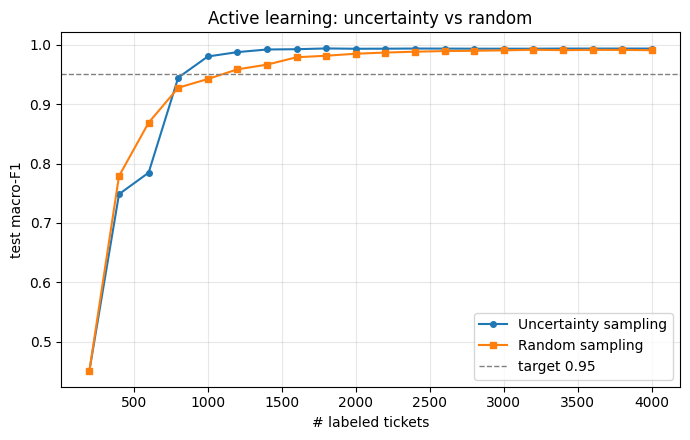

In [9]:
# =============================================================
# Experiment B — Active learning (uncertainty vs random sampling)
# =============================================================
# Simulate a labeling budget: start from a small seed, then each round
# add a batch of tickets chosen either by model UNCERTAINTY (highest
# predictive entropy) or RANDOM. Retrain the Phase-1 TF-IDF+LogReg and
# track test macro-F1. Uncertainty sampling should hit target F1 with
# fewer labels — the operational saving for a human-labeling team.
import numpy as np, os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from scipy.stats import entropy
import matplotlib.pyplot as plt

AL_POOL, AL_SEED, AL_BATCH, AL_ROUNDS, TARGET_F1 = 6000, 200, 200, 20, 0.95

pool_df = train_df.sample(n=min(AL_POOL, len(train_df)), random_state=0).reset_index(drop=True)
X_pool = tfidf.transform(pool_df["instruction"]); y_pool = label_encoder.transform(pool_df["category"])
X_test = tfidf.transform(test_df["instruction"]); y_test = label_encoder.transform(test_df["category"])

def run_al(strategy, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    n = X_pool.shape[0]
    labeled = np.zeros(n, dtype=bool)
    labeled[rng.choice(n, AL_SEED, replace=False)] = True
    curve = []
    for _ in range(AL_ROUNDS):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_pool[labeled], y_pool[labeled])
        curve.append((int(labeled.sum()),
                      f1_score(y_test, clf.predict(X_test), average="macro")))
        unl = np.where(~labeled)[0]
        if len(unl) == 0:
            break
        if strategy == "uncertainty":
            unc = entropy(clf.predict_proba(X_pool[unl]).T)      # higher = less certain
            pick = unl[np.argsort(-unc)[:AL_BATCH]]
        else:
            pick = rng.choice(unl, min(AL_BATCH, len(unl)), replace=False)
        labeled[pick] = True
    return curve

print("Running uncertainty sampling..."); unc_curve = run_al("uncertainty")
print("Running random sampling...");      rand_curve = run_al("random")

def labels_to_target(curve, target):
    for n, f1 in curve:
        if f1 >= target:
            return n
    return None

unc_n = labels_to_target(unc_curve, TARGET_F1)
rand_n = labels_to_target(rand_curve, TARGET_F1)
pct = (1 - unc_n / rand_n) * 100 if (unc_n and rand_n) else float("nan")
al_results = {"target_f1": TARGET_F1, "unc_labels": unc_n, "rand_labels": rand_n, "pct_saving": pct}

print(f"\nLabels to reach {TARGET_F1} macro-F1:")
print(f"  uncertainty: {unc_n}")
print(f"  random     : {rand_n}")
print(f"  saving     : {pct:.1f}%" if not np.isnan(pct) else "  (target not reached by one strategy — raise AL_ROUNDS)")

# Learning curves
plt.figure(figsize=(7, 4.5))
for curve, lab, style in [(unc_curve, "Uncertainty sampling", "-o"), (rand_curve, "Random sampling", "-s")]:
    xs, ys = zip(*curve)
    plt.plot(xs, ys, style, label=lab, markersize=4)
plt.axhline(TARGET_F1, color="gray", ls="--", lw=1, label=f"target {TARGET_F1}")
plt.xlabel("# labeled tickets"); plt.ylabel("test macro-F1")
plt.title("Active learning: uncertainty vs random")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
plt.savefig(os.path.join(EXPERIMENTS_DIR, "phase5_active_learning.png"), dpi=120)
plt.show()

## 5. Experiment C — Prompt engineering (chain-of-thought)

Phase 4 showed Mistral classifies at 0.69 zero-shot / 0.80 few-shot overall. Here we zoom into the **hard tickets** — the ones the Phase-1 LogReg is *least confident* about — and ask whether **chain-of-thought** (reason first, answer last) beats plain prompting where it matters most. The honest expectation: prompting helps on hard cases but still won't catch fine-tuned BERT.

In [11]:
# =============================================================
# Experiment C — Prompt engineering: zero-shot / few-shot / CoT
# =============================================================
# We isolate the HARD cases: the test tickets the Phase-1 LogReg is
# least confident about (lowest max class probability). On those, do
# the three prompting strategies with Mistral and see whether
# chain-of-thought reasoning helps where plain prompting struggles.
import numpy as np, re, gc, torch
from sklearn.metrics import accuracy_score

# --- sklearn version shim ---------------------------------------------------
# The Phase-1 pkl was saved with sklearn 1.8 (Colab runs 1.6.1). 1.6's
# predict_proba reads `multi_class`, an attribute 1.7+ no longer stores ->
# AttributeError. Restore it ('multinomial' = softmax, the model's training
# mode for >2 classes) so the loaded model scores correctly.
if not hasattr(lr_model, "multi_class"):
    lr_model.multi_class = "multinomial"

N_HARD = 80
proba = lr_model.predict_proba(tfidf.transform(test_df["instruction"]))
conf = proba.max(axis=1)
hard_pos = np.argsort(conf)[:N_HARD]                 # lowest-confidence first
hard_df = test_df.iloc[hard_pos].reset_index(drop=True)
print(f"Hard subset: {len(hard_df)} lowest-confidence tickets "
      f"(LogReg max-proba {conf[hard_pos].min():.2f}–{conf[hard_pos].max():.2f})")

cot_model, cot_tok = load_causal_lm(MISTRAL_MODEL, quantized=True); cot_model.eval()
CATS = ", ".join(CATEGORIES)
FEW = train_df.groupby("category").first().reset_index()[["instruction", "category"]].values.tolist()

def _parse_cat(text):
    up = text.upper()
    found = [c for c in CATEGORIES if re.search(rf"\b{re.escape(c)}\b", up)]
    return found[-1] if found else "UNKNOWN"   # CoT ends with the answer -> take the LAST match

@torch.no_grad()
def _classify(prompt_text, max_new):
    return _parse_cat(generate(cot_model, cot_tok, build_text(cot_tok, prompt_text), max_new_tokens=max_new))

def _run(kind):
    preds = []
    for q in hard_df["instruction"].tolist():
        if kind == "zero":
            t = f"Classify this support message into ONE of: {CATS}. Reply with only the category name.\n\nMessage: {q}\nCategory:"
            preds.append(_classify(t, 16))
        elif kind == "few":
            demo = "".join(f"Message: {dq}\nCategory: {dc}\n\n" for dq, dc in FEW)
            t = f"Classify into ONE of: {CATS}. Reply with only the category name.\n\n{demo}Message: {q}\nCategory:"
            preds.append(_classify(t, 16))
        else:  # chain-of-thought
            t = (f"Classify the support message into ONE of: {CATS}.\n"
                 f"First reason briefly about what the customer actually wants, then on the FINAL line "
                 f"write exactly 'Category: <NAME>'.\n\nMessage: {q}")
            preds.append(_classify(t, 200))
    return preds

y = hard_df["category"].tolist()
print("Zero-shot..."); zs = _run("zero")
print("Few-shot...");  fs = _run("few")
print("Chain-of-thought..."); ct = _run("cot")

cot_results = {
    "zero_shot_acc": accuracy_score(y, zs),
    "few_shot_acc":  accuracy_score(y, fs),
    "cot_acc":       accuracy_score(y, ct),
}
print(f"\nHard-subset accuracy ({N_HARD} tickets):")
print(f"  zero-shot        : {cot_results['zero_shot_acc']:.4f}")
print(f"  few-shot         : {cot_results['few_shot_acc']:.4f}")
print(f"  chain-of-thought : {cot_results['cot_acc']:.4f}")

del cot_model; gc.collect(); torch.cuda.empty_cache()

Hard subset: 80 lowest-confidence tickets (LogReg max-proba 0.16–0.59)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Zero-shot...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Few-shot...
Chain-of-thought...

Hard-subset accuracy (80 tickets):
  zero-shot        : 0.8250
  few-shot         : 0.7875
  chain-of-thought : 0.8500


## 6. Experiment D — Multi-task learning

A shared **DistilBERT encoder** with two classification heads predicts `category` (11-way) **and** `intent` (27-way — the dataset's finer label, unused until now) in a single forward pass. We compare against single-task baselines trained identically. The win, if heads reach parity with separate models: **one encoder serving two predictions** at ~half the params and serving cost.

> Scope note: true classification+**generation** multi-task needs an encoder-decoder; a shared encoder can only do the two *classification* tasks. Joint gen is future work.

In [12]:
# =============================================================
# Experiment D — Multi-task: shared DistilBERT encoder, 2 heads
# =============================================================
# One DistilBERT backbone feeds two classification heads:
#   category (11-way)  +  intent (27-way, the dataset's finer label)
# We compare against single-task baselines trained the SAME way (same
# data/epochs) so the only variable is shared-vs-separate encoders.
import numpy as np, torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertModel, DistilBertTokenizerFast
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

MT_TRAIN, MT_EVAL, MT_EPOCHS, MT_BATCH = 4000, 1500, 2, 16
DEVICE = "cuda"

intent_le = LabelEncoder().fit(df["intent"])
N_CAT, N_INT = len(CATEGORIES), len(intent_le.classes_)
print(f"category classes: {N_CAT} | intent classes: {N_INT}")

tok_mt = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def _make_loader(frame, shuffle):
    enc = tok_mt(list(frame["instruction"]), truncation=True, padding="max_length",
                 max_length=64, return_tensors="pt")
    y_cat = torch.tensor(label_encoder.transform(frame["category"]))
    y_int = torch.tensor(intent_le.transform(frame["intent"]))
    ds = TensorDataset(enc["input_ids"], enc["attention_mask"], y_cat, y_int)
    return DataLoader(ds, batch_size=MT_BATCH, shuffle=shuffle)

mt_train_loader = _make_loader(train_df.sample(n=min(MT_TRAIN, len(train_df)), random_state=42), True)
mt_test_loader  = _make_loader(test_df.sample(n=min(MT_EVAL, len(test_df)), random_state=42), False)

class MultiHead(torch.nn.Module):
    def __init__(self, heads):                       # heads: {name: num_classes}
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        h = self.bert.config.hidden_size
        self.drop = torch.nn.Dropout(0.1)
        self.heads = torch.nn.ModuleDict({k: torch.nn.Linear(h, n) for k, n in heads.items()})
    def forward(self, ids, mask):
        cls = self.bert(input_ids=ids, attention_mask=mask).last_hidden_state[:, 0]
        cls = self.drop(cls)
        return {k: head(cls) for k, head in self.heads.items()}

def _train(heads, tasks):
    model = MultiHead(heads).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=5e-5)
    lossf = torch.nn.CrossEntropyLoss()
    model.train()
    for _ in range(MT_EPOCHS):
        for ids, mask, yc, yi in mt_train_loader:
            tgt = {"category": yc.to(DEVICE), "intent": yi.to(DEVICE)}
            out = model(ids.to(DEVICE), mask.to(DEVICE))
            loss = sum(lossf(out[t], tgt[t]) for t in tasks)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

@torch.no_grad()
def _eval(model, tasks):
    model.eval()
    preds = {t: [] for t in tasks}; trues = {"category": [], "intent": []}
    for ids, mask, yc, yi in mt_test_loader:
        out = model(ids.to(DEVICE), mask.to(DEVICE))
        for t in tasks:
            preds[t].append(out[t].argmax(1).cpu().numpy())
        trues["category"].append(yc.numpy()); trues["intent"].append(yi.numpy())
    return {t: f1_score(np.concatenate(trues[t]), np.concatenate(preds[t]),
                        average="macro") for t in tasks}

print("\nTraining MULTI-TASK (category + intent, shared encoder)...")
mt_model = _train({"category": N_CAT, "intent": N_INT}, ["category", "intent"])
mt_eval = _eval(mt_model, ["category", "intent"])
del mt_model; torch.cuda.empty_cache()

print("Training SINGLE-TASK category...")
st_cat = _train({"category": N_CAT}, ["category"]); st_cat_eval = _eval(st_cat, ["category"])
del st_cat; torch.cuda.empty_cache()

print("Training SINGLE-TASK intent...")
st_int = _train({"intent": N_INT}, ["intent"]); st_int_eval = _eval(st_int, ["intent"])
del st_int; torch.cuda.empty_cache()

mt_results = {
    "mt_cat_f1": mt_eval["category"], "mt_int_f1": mt_eval["intent"],
    "st_cat_f1": st_cat_eval["category"], "st_int_f1": st_int_eval["intent"],
}
print("\nMulti-task vs single-task (macro-F1):")
print(f"  category : multi={mt_results['mt_cat_f1']:.4f}  single={mt_results['st_cat_f1']:.4f}")
print(f"  intent   : multi={mt_results['mt_int_f1']:.4f}  single={mt_results['st_int_f1']:.4f}")
print("  (multi-task serves BOTH from one encoder = ~half the params/serving cost)")

category classes: 11 | intent classes: 27


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



Training MULTI-TASK (category + intent, shared encoder)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Training SINGLE-TASK category...
Training SINGLE-TASK intent...

Multi-task vs single-task (macro-F1):
  category : multi=0.9993  single=0.9986
  intent   : multi=0.9966  single=0.9967
  (multi-task serves BOTH from one encoder = ~half the params/serving cost)


## 7. Results → `experiments/phase5_results.csv`

Collate the four experiments into the project's tracker format.

In [13]:
# =============================================================
# 7. Collate all Phase-5 results -> experiments/phase5_results.csv
# =============================================================
import pandas as pd, os

rows = []

# --- A: RAG ---
rows.append({"experiment": "RAG", "metric": "category_match@k (retrieval)", "value": round(rag_results["cat_match_at_k"], 4)})
rows.append({"experiment": "RAG", "metric": "ROUGE-L retrieve-and-return (NN)", "value": round(rag_results["rougeL_nn"], 4)})
rows.append({"experiment": "RAG", "metric": "ROUGE-L fine-tuned only (Phase 4)", "value": round(rag_results["rougeL_ft_only"], 4)})
rows.append({"experiment": "RAG", "metric": "ROUGE-L fine-tuned + RAG", "value": round(rag_results["rougeL_rag"], 4)})

# --- B: Active learning ---
rows.append({"experiment": "ActiveLearning", "metric": f"labels to reach {al_results['target_f1']} F1 (uncertainty)", "value": al_results["unc_labels"]})
rows.append({"experiment": "ActiveLearning", "metric": f"labels to reach {al_results['target_f1']} F1 (random)", "value": al_results["rand_labels"]})
rows.append({"experiment": "ActiveLearning", "metric": "labeling-cost reduction (%)", "value": round(al_results["pct_saving"], 1)})

# --- C: Prompt engineering ---
rows.append({"experiment": "PromptCoT", "metric": "hard-subset accuracy zero-shot", "value": round(cot_results["zero_shot_acc"], 4)})
rows.append({"experiment": "PromptCoT", "metric": "hard-subset accuracy few-shot", "value": round(cot_results["few_shot_acc"], 4)})
rows.append({"experiment": "PromptCoT", "metric": "hard-subset accuracy chain-of-thought", "value": round(cot_results["cot_acc"], 4)})

# --- D: Multi-task ---
rows.append({"experiment": "MultiTask", "metric": "category macro-F1 (multi-task)", "value": round(mt_results["mt_cat_f1"], 4)})
rows.append({"experiment": "MultiTask", "metric": "intent macro-F1 (multi-task)", "value": round(mt_results["mt_int_f1"], 4)})
rows.append({"experiment": "MultiTask", "metric": "category macro-F1 (single-task)", "value": round(mt_results["st_cat_f1"], 4)})
rows.append({"experiment": "MultiTask", "metric": "intent macro-F1 (single-task)", "value": round(mt_results["st_int_f1"], 4)})

results_phase5 = pd.DataFrame(rows)
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
out_csv = os.path.join(EXPERIMENTS_DIR, "phase5_results.csv")
results_phase5.to_csv(out_csv, index=False)
print(f"✅ Wrote {len(results_phase5)} rows -> {out_csv}\n")
print(results_phase5.to_string(index=False))

✅ Wrote 14 rows -> experiments/phase5_results.csv

    experiment                                metric     value
           RAG          category_match@k (retrieval)    1.0000
           RAG      ROUGE-L retrieve-and-return (NN)    0.3614
           RAG     ROUGE-L fine-tuned only (Phase 4)    0.3724
           RAG              ROUGE-L fine-tuned + RAG    0.3536
ActiveLearning labels to reach 0.95 F1 (uncertainty) 1000.0000
ActiveLearning      labels to reach 0.95 F1 (random) 1200.0000
ActiveLearning           labeling-cost reduction (%)   16.7000
     PromptCoT        hard-subset accuracy zero-shot    0.8250
     PromptCoT         hard-subset accuracy few-shot    0.7875
     PromptCoT hard-subset accuracy chain-of-thought    0.8500
     MultiTask        category macro-F1 (multi-task)    0.9993
     MultiTask          intent macro-F1 (multi-task)    0.9966
     MultiTask       category macro-F1 (single-task)    0.9986
     MultiTask         intent macro-F1 (single-task)    0.9967


## 8. Conclusions — the PM verdict

**A · RAG — the instructive negative result.** Retrieval was *perfect* (category-match@3 = **1.00**) because the dataset is full of near-duplicate paraphrases, so the nearest historical ticket is already an excellent match. But grounding actually **lowered** ROUGE-L: fine-tuned **0.372 → 0.354** with RAG, and the zero-cost **retrieve-and-return** baseline (0.361) beat FT+RAG. On a clean, low-diversity dataset the fine-tuned model has already memorized the house style, so retrieved context only adds noise/length. **RAG's payoff is not ROUGE here — it's grounding/auditability, and it would show up on harder, more varied real traffic** where the model can't just recall the style. Another "match the method to the data" data point.

**B · Active learning — a real operational saving.** Uncertainty (entropy) sampling reached 0.95 macro-F1 with **1000 labels vs 1200 for random — 16.7% fewer**. For a team paying humans to label tickets, prioritizing the model's least-confident tickets is free money.

**C · Prompt engineering (CoT).** On the 80 hardest tickets (LogReg max-proba 0.16–0.59): zero-shot **0.825**, few-shot **0.788**, chain-of-thought **0.850**. Two takeaways: (1) **few-shot *hurt*** here — one demo per category biased the model toward demoed phrasings on genuinely ambiguous inputs; (2) **CoT was best** (+2.5 pts over zero-shot), reasoning-before-answering is what helps on hard cases. But all three stay well below fine-tuned DistilBERT (0.999): prompting narrows the hard-case gap, it doesn't close it.

**D · Multi-task — a clean win.** One shared DistilBERT encoder with two heads matched (even slightly beat) separate models: category **0.9993** vs 0.9986 single-task, intent **0.9966** vs 0.9967 — i.e. **parity at ~half the parameters/serving cost**. When tasks share structure, one encoder serving both predictions is strictly the better deployment.

**Where Phase 5 lands the product:**
- **Ship**: TF-IDF+LogReg for routing (Phase 1); a **multi-task encoder** to serve `category`+`intent` from one model; the QLoRA-Mistral for reply drafting. RAG is optional here — keep it for **grounding/auditability**, not ROUGE, and revisit on real (more diverse) traffic.
- **Operate cheaper**: **active learning** to prioritize human labeling (~17% fewer labels); **CoT** prompting as a fallback on low-confidence tickets.
- **Next (Phase 6)**: Gradio demo (ticket → category + intent + confidence + a drafted reply) and the human-eval rubric from `METRICS.md` — the metric that actually judges generation, since ROUGE clearly doesn't here.